# Aircraft Acquisition Decision Tool

## Project Objective

This project develops a Python-based decision-support tool for evaluating
the economic and strategic suitability of alternative narrow-body aircraft
for a hypothetical airline.

The model integrates aircraft operating economics, airline profitability,
investment analysis, sensitivity analysis and strategic decision-making.

### Aircraft considered

- Airbus A320neo
- Boeing 737 MAX 8
- Airbus A321neo

### Key decision question

Which aircraft provides the strongest combination of financial return,
operating economics and strategic robustness under different market conditions?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Business Scenario

A hypothetical airline is evaluating the acquisition of a new narrow-body
aircraft for medium-haul operations.

The analysis assumes a representative 3,000 km route and evaluates the
economic performance of each aircraft over a 15-year planning horizon.

The model is intended as a decision-support framework rather than a
commercial aircraft procurement model.


In [ ]:
route_distance = 3000          # km
flight_time = 4                # hours
annual_utilisation = 3500      # flight hours/year

load_factor = 0.82             # 82%
ticket_price = 180             # USD/passenger
fuel_price = 0.85              # USD/kg

analysis_years = 15
discount_rate = 0.10

print("Business assumptions loaded.")

Business assumptions loaded.


## 3. Aircraft Dataset

Three narrow-body aircraft are considered in the analysis.

The initial dataset uses simplified illustrative assumptions so that the
decision model can be developed and validated before incorporating more
detailed real-world data.


In [ ]:
aircraft_data = {
    "Aircraft": [
        "A320neo",
        "737 MAX 8",
        "A321neo"
    ],

    "PurchasePrice": [
        55_000_000,
        52_000_000,
        62_000_000
    ],

    "Seats": [
        186,
        178,
        220
    ],

    "FuelBurnPerHour": [
        2400,
        2350,
        2700
    ],

    "MaintenancePerHour": [
        950,
        950,
        1050
    ],

    "CrewCostPerFlight": [
        1200,
        1200,
        1200
    ],

    "AirportCostPerFlight": [
        2500,
        2500,
        2800
    ]
}

aircraft = pd.DataFrame(aircraft_data)

aircraft


,Aircraft,PurchasePrice,Seats,FuelBurnPerHour,MaintenancePerHour,CrewCostPerFlight,AirportCostPerFlight
0,A320neo,55000000,186,2400,950,1200,2500
1,737 MAX 8,52000000,178,2350,950,1200,2500
2,A321neo,62000000,220,2700,1050,1200,2800


In [ ]:
aircraft.info()
aircraft.describe()
aircraft.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Aircraft              3 non-null      object
 1   PurchasePrice         3 non-null      int64 
 2   Seats                 3 non-null      int64 
 3   FuelBurnPerHour       3 non-null      int64 
 4   MaintenancePerHour    3 non-null      int64 
 5   CrewCostPerFlight     3 non-null      int64 
 6   AirportCostPerFlight  3 non-null      int64 
dtypes: int64(6), object(1)
memory usage: 300.0+ bytes


,0
Aircraft,0
PurchasePrice,0
Seats,0
FuelBurnPerHour,0
MaintenancePerHour,0
CrewCostPerFlight,0
AirportCostPerFlight,0


## 4. Operating Economics

### 4.1 Passenger Demand

In [ ]:
aircraft["Passengers"] = (
    aircraft["Seats"] * load_factor
)

aircraft[["Aircraft", "Seats", "Passengers"]]

,Aircraft,Seats,Passengers
0,A320neo,186,152.52
1,737 MAX 8,178,145.96
2,A321neo,220,180.40


In [ ]:
aircraft["FuelPerFlight"] = (
    aircraft["FuelBurnPerHour"] * flight_time
)

aircraft[
    ["Aircraft", "FuelBurnPerHour", "FuelPerFlight"]
]

,Aircraft,FuelBurnPerHour,FuelPerFlight
0,A320neo,2400,9600
1,737 MAX 8,2350,9400
2,A321neo,2700,10800


In [ ]:
aircraft["FuelCostPerFlight"] = (
    aircraft["FuelPerFlight"] * fuel_price
)

aircraft[
    ["Aircraft", "FuelCostPerFlight"]
]

,Aircraft,FuelCostPerFlight
0,A320neo,8160.0
1,737 MAX 8,7990.0
2,A321neo,9180.0


In [ ]:
aircraft["MaintenanceCostPerFlight"] = (
    aircraft["MaintenancePerHour"] * flight_time
)

aircraft[
    ["Aircraft", "MaintenanceCostPerFlight"]
]

,Aircraft,MaintenanceCostPerFlight
0,A320neo,3800
1,737 MAX 8,3800
2,A321neo,4200


In [ ]:
aircraft["OperatingCostPerFlight"] = (
    aircraft["FuelCostPerFlight"]
    + aircraft["MaintenanceCostPerFlight"]
    + aircraft["CrewCostPerFlight"]
    + aircraft["AirportCostPerFlight"]
)

aircraft[
    ["Aircraft", "OperatingCostPerFlight"]
]

,Aircraft,OperatingCostPerFlight
0,A320neo,15660.0
1,737 MAX 8,15490.0
2,A321neo,17380.0


In [ ]:
aircraft["RevenuePerFlight"] = (
    aircraft["Passengers"] * ticket_price
)

aircraft[
    ["Aircraft", "RevenuePerFlight"]
]

,Aircraft,RevenuePerFlight
0,A320neo,27453.6
1,737 MAX 8,26272.8
2,A321neo,32472.0


In [ ]:
aircraft["ProfitPerFlight"] = (
    aircraft["RevenuePerFlight"]
    - aircraft["OperatingCostPerFlight"]
)

aircraft[
    [
        "Aircraft",
        "RevenuePerFlight",
        "OperatingCostPerFlight",
        "ProfitPerFlight"
    ]
]

,Aircraft,RevenuePerFlight,OperatingCostPerFlight,ProfitPerFlight
0,A320neo,27453.6,15660.0,11793.6
1,737 MAX 8,26272.8,15490.0,10782.8
2,A321neo,32472.0,17380.0,15092.0


In [ ]:
annual_flights = (
    annual_utilisation / flight_time
)

annual_flights

875.0

In [ ]:
aircraft["AnnualRevenue"] = (
    aircraft["RevenuePerFlight"]
    * annual_flights
)

aircraft[
    ["Aircraft", "AnnualRevenue"]
]

,Aircraft,AnnualRevenue
0,A320neo,24021900.0
1,737 MAX 8,22988700.0
2,A321neo,28413000.0


In [ ]:
aircraft["AnnualOperatingCost"] = (
    aircraft["OperatingCostPerFlight"]
    * annual_flights
)

aircraft[
    ["Aircraft", "AnnualOperatingCost"]
]

,Aircraft,AnnualOperatingCost
0,A320neo,13702500.0
1,737 MAX 8,13553750.0
2,A321neo,15207500.0


In [ ]:
aircraft["AnnualOperatingProfit"] = (
    aircraft["AnnualRevenue"]
    - aircraft["AnnualOperatingCost"]
)

aircraft[
    ["Aircraft", "AnnualOperatingProfit"]
]

,Aircraft,AnnualOperatingProfit
0,A320neo,10319400.0
1,737 MAX 8,9434950.0
2,A321neo,13205500.0


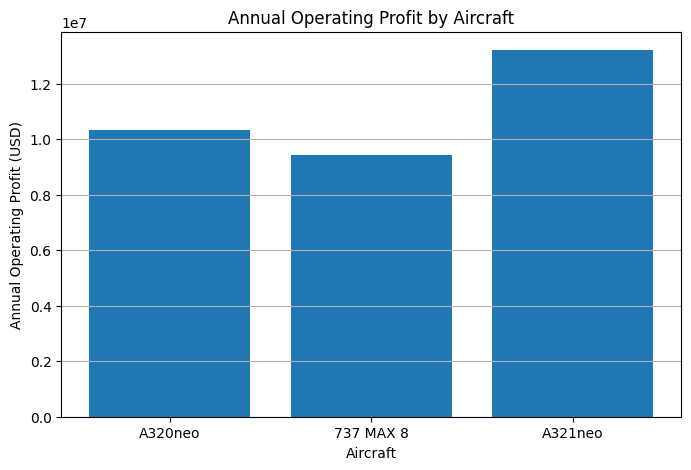

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    aircraft["Aircraft"],
    aircraft["AnnualOperatingProfit"]
)

plt.xlabel("Aircraft")
plt.ylabel("Annual Operating Profit (USD)")
plt.title("Annual Operating Profit by Aircraft")
plt.grid(axis="y")

plt.show()

In [ ]:
aircraft["ASKPerFlight"] = (
    aircraft["Seats"] * route_distance
)
aircraft["AnnualASK"] = (
    aircraft["ASKPerFlight"] * annual_flights
)

In [ ]:
aircraft["CASK"] = (
    aircraft["AnnualOperatingCost"]
    / aircraft["AnnualASK"]
)
aircraft[
    ["Aircraft", "CASK"]
]

,Aircraft,CASK
0,A320neo,0.028065
1,737 MAX 8,0.029007
2,A321neo,0.026333


In [ ]:
aircraft["RASK"] = (
    aircraft["AnnualRevenue"]
    / aircraft["AnnualASK"]
)

aircraft[
    ["Aircraft", "RASK"]
]

,Aircraft,RASK
0,A320neo,0.0492
1,737 MAX 8,0.0492
2,A321neo,0.0492


In [ ]:
aircraft[
    [
        "Aircraft",
        "CASK",
        "RASK"
    ]
]
aircraft["RASK_CASK_Margin"] = (
    aircraft["RASK"]
    - aircraft["CASK"]
)

aircraft[
    [
        "Aircraft",
        "RASK",
        "CASK",
        "RASK_CASK_Margin"
    ]
]

,Aircraft,RASK,CASK,RASK_CASK_Margin
0,A320neo,0.0492,0.028065,0.021135
1,737 MAX 8,0.0492,0.029007,0.020193
2,A321neo,0.0492,0.026333,0.022867


In [ ]:
aircraft["BreakEvenLoadFactor"] = (
    aircraft["OperatingCostPerFlight"]
    / (
        aircraft["Seats"]
        * ticket_price
    )
)

aircraft[
    ["Aircraft", "BreakEvenLoadFactor"]
]
aircraft["BreakEvenLoadFactorPercent"] = (
    aircraft["BreakEvenLoadFactor"] * 100
)

aircraft[
    ["Aircraft", "BreakEvenLoadFactorPercent"]
]

,Aircraft,BreakEvenLoadFactorPercent
0,A320neo,46.774194
1,737 MAX 8,48.345818
2,A321neo,43.888889


In [ ]:
aircraft["BreakEvenFare"] = (
    aircraft["OperatingCostPerFlight"]
    / aircraft["Passengers"]
)

aircraft[
    ["Aircraft", "BreakEvenFare"]
]

,Aircraft,BreakEvenFare
0,A320neo,102.675059
1,737 MAX 8,106.124966
2,A321neo,96.341463


In [ ]:
operating_summary = aircraft[
    [
        "Aircraft",
        "Seats",
        "Passengers",
        "FuelCostPerFlight",
        "OperatingCostPerFlight",
        "RevenuePerFlight",
        "ProfitPerFlight",
        "CASK",
        "RASK",
        "BreakEvenLoadFactorPercent",
        "BreakEvenFare"
    ]
]

operating_summary

,Aircraft,Seats,Passengers,FuelCostPerFlight,OperatingCostPerFlight,RevenuePerFlight,ProfitPerFlight,CASK,RASK,BreakEvenLoadFactorPercent,BreakEvenFare
0,A320neo,186,152.52,8160.0,15660.0,27453.6,11793.6,0.028065,0.0492,46.774194,102.675059
1,737 MAX 8,178,145.96,7990.0,15490.0,26272.8,10782.8,0.029007,0.0492,48.345818,106.124966
2,A321neo,220,180.40,9180.0,17380.0,32472.0,15092.0,0.026333,0.0492,43.888889,96.341463


# 5. Investment Analysis

The aircraft acquisition decision cannot be based solely on operating
profit. The model therefore evaluates the aircraft as a long-term capital
investment using discounted cash-flow analysis.

In [ ]:
residual_value_percent = 0.20

aircraft["ResidualValue"] = (
    aircraft["PurchasePrice"]
    * residual_value_percent
)

aircraft[
    ["Aircraft", "PurchasePrice", "ResidualValue"]
]

,Aircraft,PurchasePrice,ResidualValue
0,A320neo,55000000,11000000.0
1,737 MAX 8,52000000,10400000.0
2,A321neo,62000000,12400000.0


In [ ]:
def calculate_npv(
    initial_cost,
    annual_cash_flow,
    years,
    discount_rate,
    residual_value
):

    npv = -initial_cost

    for year in range(1, years + 1):

        cash_flow = annual_cash_flow

        if year == years:
            cash_flow += residual_value

        npv += (
            cash_flow
            / (1 + discount_rate) ** year
        )

    return npv

In [ ]:
aircraft["NPV"] = aircraft.apply(
    lambda row: calculate_npv(
        row["PurchasePrice"],
        row["AnnualOperatingProfit"],
        analysis_years,
        discount_rate,
        row["ResidualValue"]
    ),
    axis=1
)

aircraft[
    ["Aircraft", "NPV"]
]

,Aircraft,NPV
0,A320neo,2.612349e+07
1,737 MAX 8,2.225266e+07
2,A321neo,4.141054e+07


In [ ]:
!pip install numpy-financial
import numpy_financial as npf

def calculate_irr(
    initial_cost,
    annual_cash_flow,
    years,
    residual_value
):

    cash_flows = [-initial_cost]

    for year in range(1, years + 1):

        cash_flow = annual_cash_flow

        if year == years:
            cash_flow += residual_value

        cash_flows.append(cash_flow)

    return npf.irr(cash_flows)

In [ ]:
aircraft["IRR"] = aircraft.apply(
    lambda row: calculate_irr(
        row["PurchasePrice"],
        row["AnnualOperatingProfit"],
        analysis_years,
        row["ResidualValue"]
    ),
    axis=1
)

aircraft[
    ["Aircraft", "IRR"]
]

aircraft["IRR_Percent"] = (
    aircraft["IRR"] * 100
)

In [ ]:
aircraft["PaybackYears"] = (
    aircraft["PurchasePrice"]
    / aircraft["AnnualOperatingProfit"]
)

aircraft[
    ["Aircraft", "PaybackYears"]
]

,Aircraft,PaybackYears
0,A320neo,5.329767
1,737 MAX 8,5.511423
2,A321neo,4.695013


In [ ]:
investment_summary = aircraft[
    [
        "Aircraft",
        "PurchasePrice",
        "AnnualOperatingProfit",
        "NPV",
        "IRR_Percent",
        "PaybackYears",
        "ResidualValue"
    ]
]

investment_summary

,Aircraft,PurchasePrice,AnnualOperatingProfit,NPV,IRR_Percent,PaybackYears,ResidualValue
0,A320neo,55000000,10319400.0,2.612349e+07,17.381113,5.329767,11000000.0
1,737 MAX 8,52000000,9434950.0,2.225266e+07,16.680115,5.511423,10400000.0
2,A321neo,62000000,13205500.0,4.141054e+07,20.207770,4.695013,12400000.0


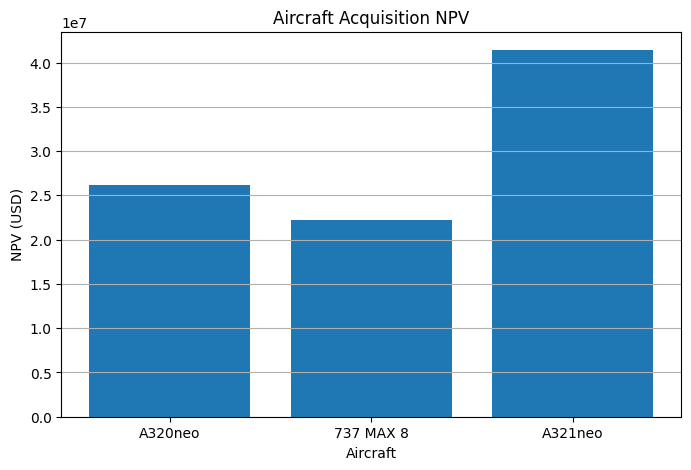

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    aircraft["Aircraft"],
    aircraft["NPV"]
)

plt.xlabel("Aircraft")
plt.ylabel("NPV (USD)")
plt.title("Aircraft Acquisition NPV")
plt.grid(axis="y")

plt.show()

In [ ]:
fuel_prices = np.arange(
    0.60,
    1.21,
    0.10
)

fuel_results = []

for fuel in fuel_prices:

    for _, row in aircraft.iterrows():

        fuel_cost = (
            row["FuelPerFlight"] * fuel
        )

        operating_cost = (
            fuel_cost
            + row["MaintenanceCostPerFlight"]
            + row["CrewCostPerFlight"]
            + row["AirportCostPerFlight"]
        )

        revenue = row["RevenuePerFlight"]

        annual_profit = (
            revenue - operating_cost
        ) * annual_flights

        npv = calculate_npv(
            row["PurchasePrice"],
            annual_profit,
            analysis_years,
            discount_rate,
            row["ResidualValue"]
        )

        fuel_results.append({
            "Aircraft": row["Aircraft"],
            "FuelPrice": fuel,
            "NPV": npv
        })

fuel_df = pd.DataFrame(fuel_results)

fuel_df.head()

,Aircraft,FuelPrice,NPV
0,A320neo,0.6,4.209626e+07
1,737 MAX 8,0.6,3.789266e+07
2,A321neo,0.6,5.937991e+07
3,A320neo,0.7,3.570715e+07
4,737 MAX 8,0.7,3.163666e+07


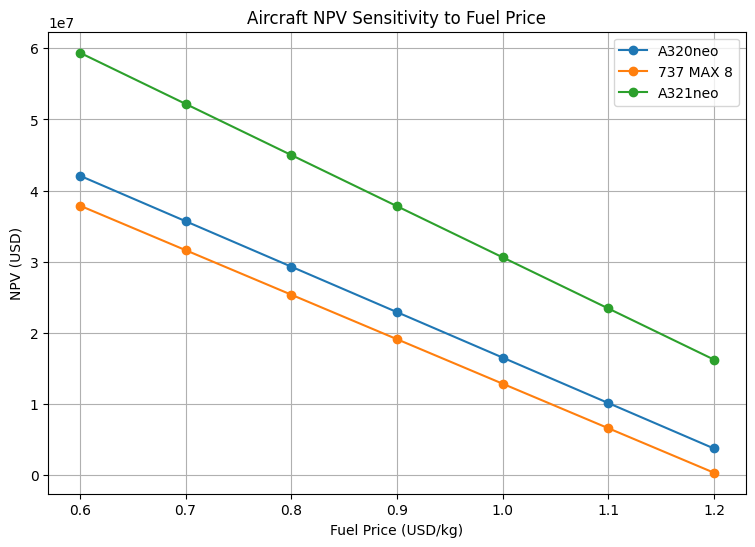

In [ ]:
plt.figure(figsize=(9, 6))

for name in fuel_df["Aircraft"].unique():

    subset = fuel_df[
        fuel_df["Aircraft"] == name
    ]

    plt.plot(
        subset["FuelPrice"],
        subset["NPV"],
        marker="o",
        label=name
    )

plt.xlabel("Fuel Price (USD/kg)")
plt.ylabel("NPV (USD)")
plt.title("Aircraft NPV Sensitivity to Fuel Price")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
load_factors = np.arange(
    0.60,
    0.96,
    0.05
)

load_results = []

for lf in load_factors:

    for _, row in aircraft.iterrows():

        passengers = row["Seats"] * lf

        revenue = (
            passengers * ticket_price
        )

        annual_profit = (
            revenue
            - row["OperatingCostPerFlight"]
        ) * annual_flights

        npv = calculate_npv(
            row["PurchasePrice"],
            annual_profit,
            analysis_years,
            discount_rate,
            row["ResidualValue"]
        )

        load_results.append({
            "Aircraft": row["Aircraft"],
            "LoadFactor": lf,
            "NPV": npv
        })

load_df = pd.DataFrame(load_results)

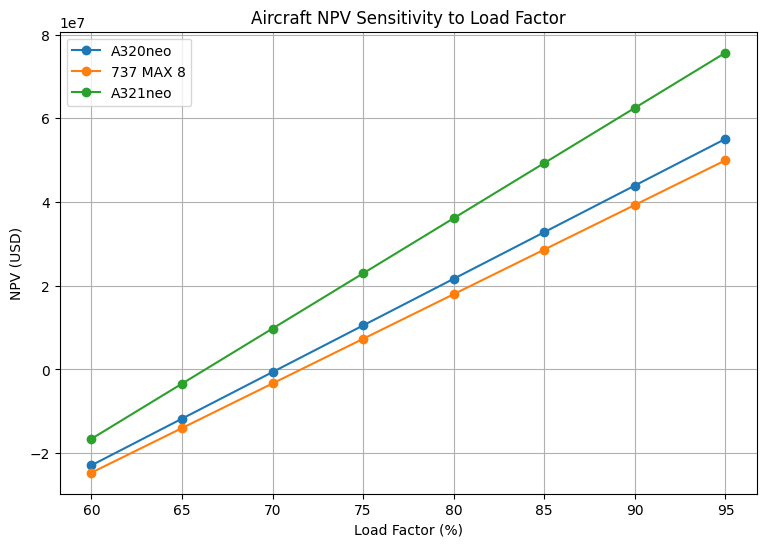

In [ ]:
plt.figure(figsize=(9, 6))

for name in load_df["Aircraft"].unique():

    subset = load_df[
        load_df["Aircraft"] == name
    ]

    plt.plot(
        subset["LoadFactor"] * 100,
        subset["NPV"],
        marker="o",
        label=name
    )

plt.xlabel("Load Factor (%)")
plt.ylabel("NPV (USD)")
plt.title("Aircraft NPV Sensitivity to Load Factor")
plt.legend()
plt.grid(True)

plt.show()

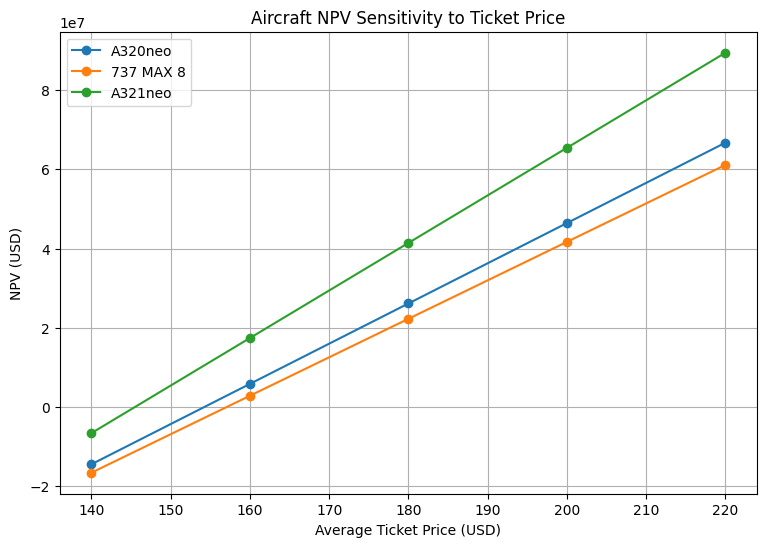

In [ ]:
ticket_prices = np.arange(
    140,
    221,
    20
)

fare_results = []

for fare in ticket_prices:

    for _, row in aircraft.iterrows():

        passengers = (
            row["Seats"] * load_factor
        )

        revenue = (
            passengers * fare
        )

        annual_profit = (
            revenue
            - row["OperatingCostPerFlight"]
        ) * annual_flights

        npv = calculate_npv(
            row["PurchasePrice"],
            annual_profit,
            analysis_years,
            discount_rate,
            row["ResidualValue"]
        )

        fare_results.append({
            "Aircraft": row["Aircraft"],
            "TicketPrice": fare,
            "NPV": npv
        })

fare_df = pd.DataFrame(fare_results)

plt.figure(figsize=(9, 6))

for name in fare_df["Aircraft"].unique():

    subset = fare_df[
        fare_df["Aircraft"] == name
    ]

    plt.plot(
        subset["TicketPrice"],
        subset["NPV"],
        marker="o",
        label=name
    )

plt.xlabel("Average Ticket Price (USD)")
plt.ylabel("NPV (USD)")
plt.title("Aircraft NPV Sensitivity to Ticket Price")
plt.legend()
plt.grid(True)

plt.show()

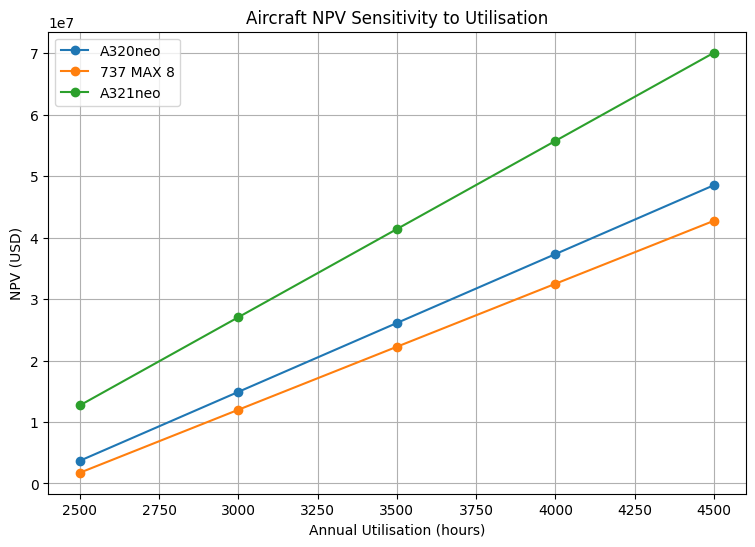

In [ ]:
utilisation_levels = np.arange(
    2500,
    4501,
    500
)

utilisation_results = []

for hours in utilisation_levels:

    flights = hours / flight_time

    for _, row in aircraft.iterrows():

        annual_profit = (
            row["ProfitPerFlight"]
            * flights
        )

        npv = calculate_npv(
            row["PurchasePrice"],
            annual_profit,
            analysis_years,
            discount_rate,
            row["ResidualValue"]
        )

        utilisation_results.append({
            "Aircraft": row["Aircraft"],
            "AnnualHours": hours,
            "NPV": npv
        })

utilisation_df = pd.DataFrame(
    utilisation_results
)

plt.figure(figsize=(9, 6))

for name in utilisation_df["Aircraft"].unique():

    subset = utilisation_df[
        utilisation_df["Aircraft"] == name
    ]

    plt.plot(
        subset["AnnualHours"],
        subset["NPV"],
        marker="o",
        label=name
    )

plt.xlabel("Annual Utilisation (hours)")
plt.ylabel("NPV (USD)")
plt.title("Aircraft NPV Sensitivity to Utilisation")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
scenarios = {
    "Conservative": {
        "load_factor": 0.70,
        "fuel_price": 1.10,
        "ticket_price": 160,
        "annual_hours": 2800
    },

    "Base Case": {
        "load_factor": 0.82,
        "fuel_price": 0.85,
        "ticket_price": 180,
        "annual_hours": 3500
    },

    "High Growth": {
        "load_factor": 0.90,
        "fuel_price": 0.70,
        "ticket_price": 200,
        "annual_hours": 4200
    }
}

In [ ]:
scenario_results = []

for scenario_name, assumptions in scenarios.items():

    lf = assumptions["load_factor"]
    fuel = assumptions["fuel_price"]
    fare = assumptions["ticket_price"]
    hours = assumptions["annual_hours"]

    flights = hours / flight_time

    for _, row in aircraft.iterrows():

        passengers = row["Seats"] * lf

        revenue = passengers * fare

        fuel_cost = (
            row["FuelPerFlight"] * fuel
        )

        operating_cost = (
            fuel_cost
            + row["MaintenanceCostPerFlight"]
            + row["CrewCostPerFlight"]
            + row["AirportCostPerFlight"]
        )

        annual_profit = (
            revenue - operating_cost
        ) * flights

        npv = calculate_npv(
            row["PurchasePrice"],
            annual_profit,
            analysis_years,
            discount_rate,
            row["ResidualValue"]
        )

        scenario_results.append({
            "Scenario": scenario_name,
            "Aircraft": row["Aircraft"],
            "AnnualProfit": annual_profit,
            "NPV": npv
        })

scenario_df = pd.DataFrame(
    scenario_results
)

scenario_df

,Scenario,Aircraft,AnnualProfit,NPV
0,Conservative,A320neo,1940400.0,-3.760785e+07
1,Conservative,737 MAX 8,1467200.0,-3.835068e+07
2,Conservative,A321neo,3192000.0,-3.475293e+07
3,Base Case,A320neo,10319400.0,2.612349e+07
4,Base Case,737 MAX 8,9434950.0,2.225266e+07
5,Base Case,A321neo,13205500.0,4.141054e+07
6,High Growth,A320neo,20223000.0,1.014511e+08
7,High Growth,737 MAX 8,18858000.0,9.392512e+07
8,High Growth,A321neo,25032000.0,1.313638e+08


In [ ]:
scenario_pivot = scenario_df.pivot(
    index="Aircraft",
    columns="Scenario",
    values="NPV"
)

scenario_pivot

Scenario,Base Case,Conservative,High Growth
Aircraft,,,
737 MAX 8,2.225266e+07,-3.835068e+07,9.392512e+07
A320neo,2.612349e+07,-3.760785e+07,1.014511e+08
A321neo,4.141054e+07,-3.475293e+07,1.313638e+08


In [ ]:
scenario_winners = {}

for scenario in scenario_df["Scenario"].unique():

    subset = scenario_df[
        scenario_df["Scenario"] == scenario
    ]

    winner = subset.loc[
        subset["NPV"].idxmax(),
        "Aircraft"
    ]

    scenario_winners[scenario] = winner

scenario_winners

{'Conservative': 'A321neo', 'Base Case': 'A321neo', 'High Growth': 'A321neo'}

In [ ]:
strategic_scores = pd.DataFrame({
    "Aircraft": [
        "A320neo",
        "737 MAX 8",
        "A321neo"
    ],

    "Flexibility": [
        8,
        8,
        7
    ],

    "Capacity": [
        7,
        6,
        10
    ],

    "FuelEfficiency": [
        9,
        9,
        7
    ]
})

strategic_scores

,Aircraft,Flexibility,Capacity,FuelEfficiency
0,A320neo,8,7,9
1,737 MAX 8,8,6,9
2,A321neo,7,10,7


In [ ]:
def normalise_higher_better(series):

    return (
        series - series.min()
    ) / (
        series.max() - series.min()
    )

def normalise_lower_better(series):

    return (
        series.max() - series
    ) / (
        series.max() - series.min()
    )

In [ ]:
decision = aircraft[
    [
        "Aircraft",
        "NPV",
        "CASK",
        "BreakEvenLoadFactor",
        "PurchasePrice"
    ]
].copy()

decision["NPVScore"] = normalise_higher_better(
    decision["NPV"]
)

decision["CASKScore"] = normalise_lower_better(
    decision["CASK"]
)

decision["BreakEvenScore"] = normalise_lower_better(
    decision["BreakEvenLoadFactor"]
)

decision["PurchasePriceScore"] = normalise_lower_better(
    decision["PurchasePrice"]
)

In [ ]:
decision = decision.merge(
    strategic_scores,
    on="Aircraft"
)

decision

,Aircraft,NPV,CASK,BreakEvenLoadFactor,PurchasePrice,NPVScore,CASKScore,BreakEvenScore,PurchasePriceScore,Flexibility,Capacity,FuelEfficiency
0,A320neo,2.612349e+07,0.028065,0.467742,55000000,0.202049,0.352625,0.352625,0.7,8,7,9
1,737 MAX 8,2.225266e+07,0.029007,0.483458,52000000,0.000000,0.000000,0.000000,1.0,8,6,9
2,A321neo,4.141054e+07,0.026333,0.438889,62000000,1.000000,1.000000,1.000000,0.0,7,10,7


In [ ]:
decision["FlexibilityScore"] = (
    decision["Flexibility"] / 10
)

decision["CapacityScore"] = (
    decision["Capacity"] / 10
)

decision["FuelEfficiencyScore"] = (
    decision["FuelEfficiency"] / 10
)

In [ ]:
decision["DecisionScore"] = (
    decision["NPVScore"] * 0.30
    + decision["CASKScore"] * 0.20
    + decision["BreakEvenScore"] * 0.15
    + decision["PurchasePriceScore"] * 0.10
    + decision["FuelEfficiencyScore"] * 0.10
    + decision["CapacityScore"] * 0.10
    + decision["FlexibilityScore"] * 0.05
)

decision[
    [
        "Aircraft",
        "DecisionScore"
    ]
].sort_values(
    "DecisionScore",
    ascending=False
)

,Aircraft,DecisionScore
2,A321neo,0.855000
0,A320neo,0.454033
1,737 MAX 8,0.290000


In [ ]:
decision["Rank"] = (
    decision["DecisionScore"]
    .rank(
        ascending=False,
        method="min"
    )
)

decision[
    [
        "Aircraft",
        "DecisionScore",
        "Rank"
    ]
].sort_values("Rank")

,Aircraft,DecisionScore,Rank
2,A321neo,0.855000,1.0
0,A320neo,0.454033,2.0
1,737 MAX 8,0.290000,3.0


In [ ]:
fuel_test = np.arange(
    0.60,
    1.21,
    0.10
)

load_test = np.arange(
    0.65,
    0.96,
    0.05
)

utilisation_test = np.arange(
    2500,
    4501,
    500
)

In [ ]:
final_results = aircraft[
    [
        "Aircraft",
        "PurchasePrice",
        "Seats",
        "AnnualRevenue",
        "AnnualOperatingCost",
        "AnnualOperatingProfit",
        "CASK",
        "RASK",
        "BreakEvenLoadFactorPercent",
        "NPV",
        "IRR_Percent",
        "PaybackYears"
    ]
].copy()

final_results

,Aircraft,PurchasePrice,Seats,AnnualRevenue,AnnualOperatingCost,AnnualOperatingProfit,CASK,RASK,BreakEvenLoadFactorPercent,NPV,IRR_Percent,PaybackYears
0,A320neo,55000000,186,24021900.0,13702500.0,10319400.0,0.028065,0.0492,46.774194,2.612349e+07,17.381113,5.329767
1,737 MAX 8,52000000,178,22988700.0,13553750.0,9434950.0,0.029007,0.0492,48.345818,2.225266e+07,16.680115,5.511423
2,A321neo,62000000,220,28413000.0,15207500.0,13205500.0,0.026333,0.0492,43.888889,4.141054e+07,20.207770,4.695013


In [ ]:
final_results.round(2)

,Aircraft,PurchasePrice,Seats,AnnualRevenue,AnnualOperatingCost,AnnualOperatingProfit,CASK,RASK,BreakEvenLoadFactorPercent,NPV,IRR_Percent,PaybackYears
0,A320neo,55000000,186,24021900.0,13702500.0,10319400.0,0.03,0.05,46.77,26123489.40,17.38,5.33
1,737 MAX 8,52000000,178,22988700.0,13553750.0,9434950.0,0.03,0.05,48.35,22252657.15,16.68,5.51
2,A321neo,62000000,220,28413000.0,15207500.0,13205500.0,0.03,0.05,43.89,41410544.33,20.21,4.70


# 6. Final Recommendation

The final aircraft recommendation is based on a combination of financial
performance, operating economics, demand risk and strategic considerations.

The model does not define the aircraft with the highest NPV as automatically
being the optimal choice. Instead, the preferred aircraft is the option
that provides the strongest overall economic and strategic performance
under the evaluated operating scenarios.

In [ ]:
best_aircraft = decision.loc[
    decision["DecisionScore"].idxmax(),
    "Aircraft"
]

best_score = decision.loc[
    decision["DecisionScore"].idxmax(),
    "DecisionScore"
]

print(
    f"Recommended aircraft: {best_aircraft}"
)

print(
    f"Decision score: {best_score:.3f}"
)

Recommended aircraft: A321neo
Decision score: 0.855
